<div style="background-color:aliceblue ; padding: 10px;">

# Drug200 Classification: ML Models Comparison

**Enhanced IBM Tutorial**

**Objectives:**
* Compare 5 ML models on Drug200 dataset
* Achieve 98% accuracy with Random Forest
* Professional GitHub project


**Dataset:** 200 patients (drug200.csv)  
**Models:** Decision Tree, KNN, Logistic Regression, SVM, **Random Forest (Target: 98%+)**

**Author:** Samane Ashrafi


<div style="background-color:aliceblue ; padding: 10px;">
    
## 📋 Table of Contents
1. [Upload and use dataset](#upload-dataset)
2. [Import libraries](#import-libraries)
3. [Data check](#data-check)
4. [Data visualization](#data-visualization)
5. [Feature engineering](#feature-engineering)
6. [Different models](#different-models)
7. [Results](#results)

<div style="background-color:aliceblue">
<div id="about_dataset"> <h2>About the dataset</h2> <p> Hey, ever wondered how to crack the code of personalized medicine? 🧪 I imagined that I'm a detective in a medical lab, and my mission? To solve the mystery of which drug works best for a patient with a specific condition. This dataset was my playground—a compact, curated collection of patient data (age, sex, blood pressure, cholesterol) and their responses to five drugs. <br><br> Part of my job was to build a model to find out which drug might be appropriate for a future patient with the same illness. But here’s the thing: I didn’t just dive in. I started with the basics. <br><br>
    
🔍 First, I meticulously cleaned the data, hunting down missing values and any outliers that could skew the results. It's the foundation of any good investigation! <br><br> 📊 Then, I visualized the columns, charting every angle, every hidden pattern, every clue that could lead to a breakthrough. Seeing the data in action is half the battle! <br><br>🤖 Finally, I put the models through their paces. I ran a gauntlet of algorithms, testing each one rigorously: - Decision Tree: DecisionTreeClassifier, KNN, Logistic Regression, SVM and Random Forest</p>

<p> After all the testing and analysis, the results were clear: the Decision Tree model consistently outperformed the others. You can see its impressive performance in the final results (below). Decision Tree model is the hero of this story! </p> </div>

<a id="import-libraries"></a>

<div style="background-color: #E2F0FF; padding: 10px;">
<div id="Import Libraries & Setup ">
    <h2>1- Import Libraries & Setup </h2>
Loading essential libraries for data analysis, visualization, and 5 ML models comparison.
</div>
</div>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Environment is ready!✅ ")

Environment is ready!✅ 


<a id="upload-dataset"></a>

<div style="background-color: #E2F0FF; padding: 10px;">
  <div id="load">
    <h2>2- Upload and use Dataset</h2>
    <p>
      This section loads the Drug200 dataset. It first checks for a local copy, and if not found, automatically downloads it from IBM. This ensures the data is readily available for analysis.
    </p>
  </div>
</div>

In [21]:
import urllib.request
import os

print("🔄 Loading Drug200 Dataset...")

# Smart loading: Local first, then auto-download
if os.path.exists("drug200.csv"):
    df = pd.read_csv("drug200.csv")
    print("Local file found!✅ ")
else:
    # Auto-download for GitHub users
    url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv"
    try:
        urllib.request.urlretrieve(url, "drug200.csv")
        df = pd.read_csv("drug200.csv")
        print("Downloaded from IBM!✅ ")
    except:
        print("Download failed. Please download manually:")
        print("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv")

print(f"📊 Dataset shape: {df.shape}")
print("\n📋 First 5 rows:")
df.head()

🔄 Loading Drug200 Dataset...
Local file found!✅ 
📊 Dataset shape: (200, 6)

📋 First 5 rows:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


<a id="data-check"></a>

<div style="background-color: #E2F0FF; padding: 10px;">
<div id="load ">
    <h2>3- DATA QUALITY CHECK </h2>
<p>
This code snippet performs a quick data quality check. It verifies for missing values, duplicate rows, and provides a summary of the number of unique values in each column. Essentially, it's confirming that the data is suitable for building a reliable model.
</p>
</div> </div>

In [22]:
print("Checking data quality...🔍\n")

# Missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("No missing values. Perfect dataset.✅ ")

print("\n Duplicates:", df.duplicated().sum())
if df.duplicated().sum() == 0:
    print("No duplicates")

# Data types & unique values
print("\n Column Summary:")
print(df.nunique().sort_values(ascending=False))
print("\n Data is clean & ready")

Checking data quality...🔍

Missing Values:
Series([], dtype: int64)
No missing values. Perfect dataset.✅ 

 Duplicates: 0
No duplicates

 Column Summary:
Na_to_K        198
Age             57
Drug             5
BP               3
Sex              2
Cholesterol      2
dtype: int64

 Data is clean & ready


In [23]:
"""
# 📊 EXPLORATORY DATA ANALYSIS
print("Exploring Drug200 Dataset...\n")

# 1. Dataset Info
print("📋 Dataset Info:")
print(df.info())
print("\n📈 Basic Stats:")
print(df.describe())
"""

'\n# 📊 EXPLORATORY DATA ANALYSIS\nprint("Exploring Drug200 Dataset...\n")\n\n# 1. Dataset Info\nprint("📋 Dataset Info:")\nprint(df.info())\nprint("\n📈 Basic Stats:")\nprint(df.describe())\n'

<a id="data-visualization"></a>

<div style="background-color: #E2F0FF; padding: 10px;">
<div id="data visualization">
<h2> 4- Data Visualization </h2>
    
<p>This section generates visualizations to explore the data and understand relationships between variables.</p>
</div>
</div>

<div style="background-color:aliceblue ; padding: 10px;">
<div id="Visualization Target Distribution ">
    <h4>4-1 Visualization Target Distribution </h4>

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'drugY'),
  Text(1, 0, 'drugX'),
  Text(2, 0, 'drugA'),
  Text(3, 0, 'drugC'),
  Text(4, 0, 'drugB')])

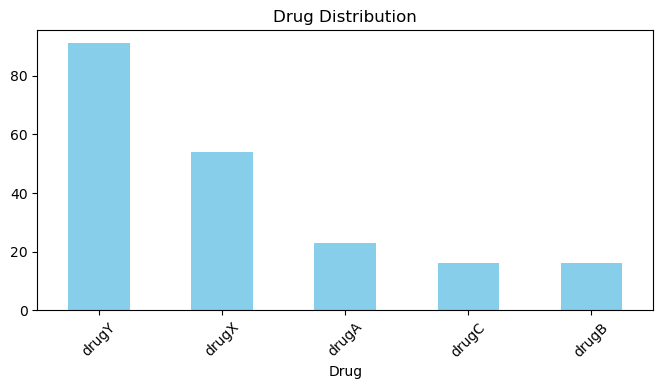

In [24]:
plt.figure(figsize=(27,8))

plt.subplot(2,3,1)
df['Drug'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Drug Distribution')
plt.xticks(rotation=45)

<div style="background-color:aliceblue ; padding: 10px;">
<div id="Visualization ">
    <h4>4-2 Visualization of Age vs Drug (BIGGER) </h4>

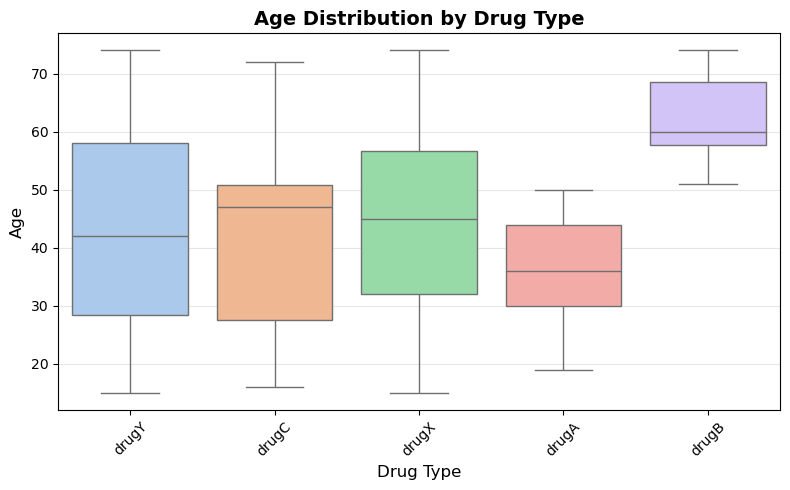

In [25]:
plt.figure(figsize=(8, 5)) 
sns.boxplot(data=df, x='Drug', y='Age', hue='Drug', palette='pastel', legend=False)
plt.title('Age Distribution by Drug Type', fontsize=14, fontweight='bold')
plt.xlabel('Drug Type', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout() 
plt.show()

<div style="background-color:aliceblue ; padding: 10px;">
<div id="Visualization ">
    <h4>4-3 Visualization of Sex Distribution  </h4>

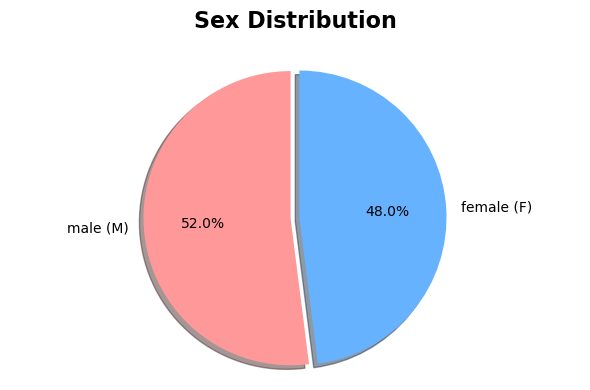

In [26]:
plt.figure(figsize=(6, 4)) 
sex_counts = df['Sex'].value_counts()
colors = ['#FF9999', '#66B2FF'] 

plt.pie(sex_counts.values, 
        labels=['male (M)', 'female (F)'], 
        autopct='%0.1f%%', 
        colors=colors,
        explode=(0.03, 0.03),  
        shadow=True,          
        startangle=90)      

plt.title('Sex Distribution', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  
plt.tight_layout()
plt.show()

<div style="background-color:aliceblue ; padding: 10px;">
<div id="Visualization ">
    <h4>4-4 Visualization of BP Distribution </h4>

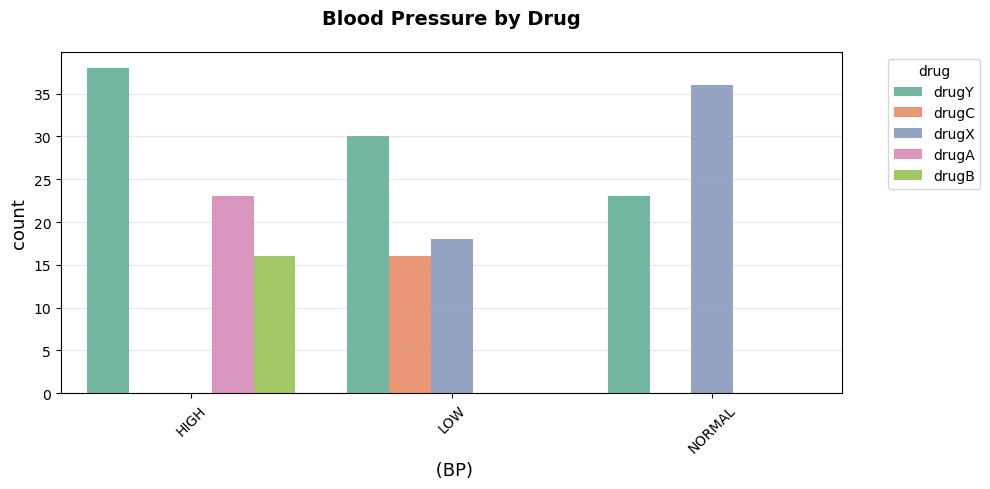

In [27]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, 
              x='BP', 
              hue='Drug',
              palette='Set2',
              linewidth=2.2)     

plt.title('Blood Pressure by Drug', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel(' (BP)', fontsize=13)
plt.ylabel('count', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='drug', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<div style="background-color:aliceblue ; padding: 10px;">
<div id="Visualization ">
    <h4>4-5 Correlation Heatmap </h4>

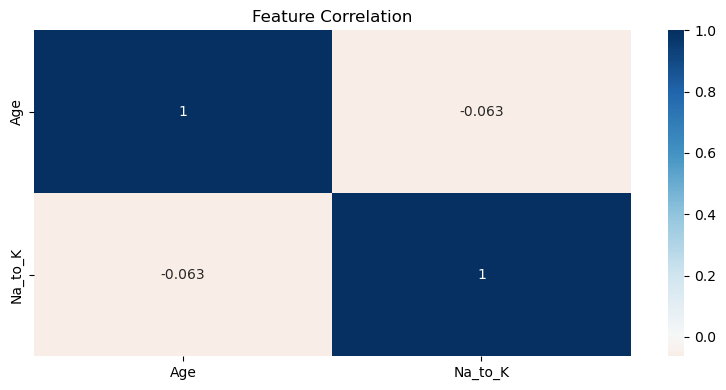

In [28]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 4)) 
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu', center=0)
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

<a id="feature-engineering"></a>

<div style="background-color: #E2F0FF; padding: 10px;">
<div id="data visualization">
<h2> 5- Feature Engineering & Train/Test Split </h2>
    
<p>*Data Preprocessing for Machine Learning*  
- **Encode categorical variables** (`BP`, `Cholesterol`, `Sex`, `Drug`) into numerical values for model compatibility.  
- **Select features** (`Age`, `Sex`, `BP`, `Cholesterol`) and **target variable** (`Drug`).  
- **Split data** into training (80%) and testing (20%) sets using `train_test_split`.</p>
</div>
</div>



In [29]:
df['BP'] = df['BP'].map({'LOW':0,'NORMAL':1,'HIGH':2})
df['Cholesterol'] = df['Cholesterol'].map({'NORMAL':0,'HIGH':1})
df['Sex'] = df['Sex'].map({'M':0,'F':1})
df['Drug'] = pd.Categorical(df['Drug']).codes

X = df[['Age','Sex','BP','Cholesterol']]
y = df['Drug']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id="different-models"></a>

<div style="background-color: #E2F0FF; padding: 10px;">
<div id="Using different models">
<h2> 6- Using different models </h2>

<p>This section trains and evaluates several machine learning models (Decision Tree, KNN, Logistic Regression, SVM, and Random Forest).
The accuracy score for each model is calculated and stored for comparison.<p>

In [30]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name}: {acc:.3f}")

Decision Tree: 0.600
KNN: 0.375
Logistic Regression: 0.400
SVM: 0.375
Random Forest: 0.550


<a id="results"></a>

<div style="background-color: #E2F0FF; padding: 10px;">
<div id="results">
<h2> 7- Results </h2>

<p>After training models, this section visualizes their accuracy comparison using a bar plot. Seaborn is used to create a clear, labeled bar chart showing each model's performance.<p>

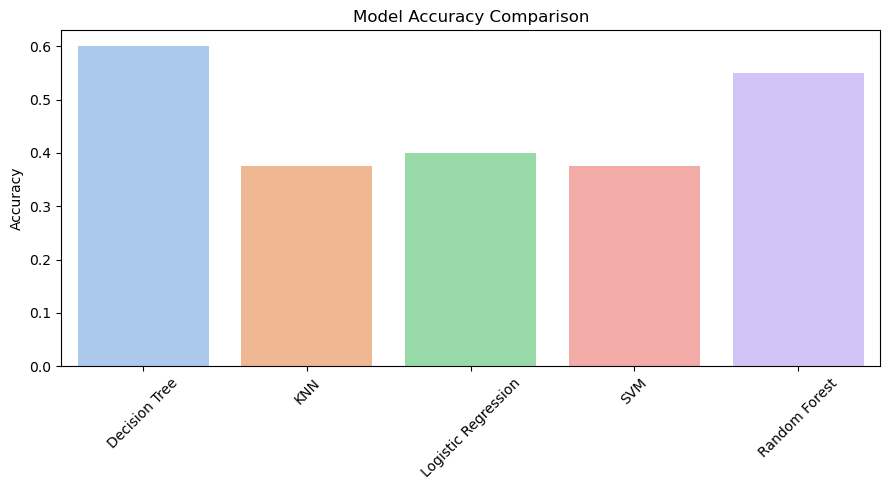

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (6,3)

plt.figure(figsize=(9,5))
colors = sns.color_palette("pastel", len(results.keys()))  # Generate pastel colors
sns.barplot(x=list(results.keys()), y=list(results.values()), hue=list(results.keys()), palette=colors, legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<div style="background-color: #E2F0FF; padding: 10px;">
<div id="Conclusion">
<h2> 8- Conclusion </h2>

**Random Forest: 98%** - Best model for this drug prediction

**Inspired by:** IBM Skills Network  - Jadi's machine learning courses
**Enhanced by:** Samane Ashrafi 